# CommonRoad-io
## Transform Intersection Definition into new format

This tutorial shows how CommonRoad Intersection scenarios can be transformed into new format. The following image illustrate the new definition of CommonRoad Intersection:
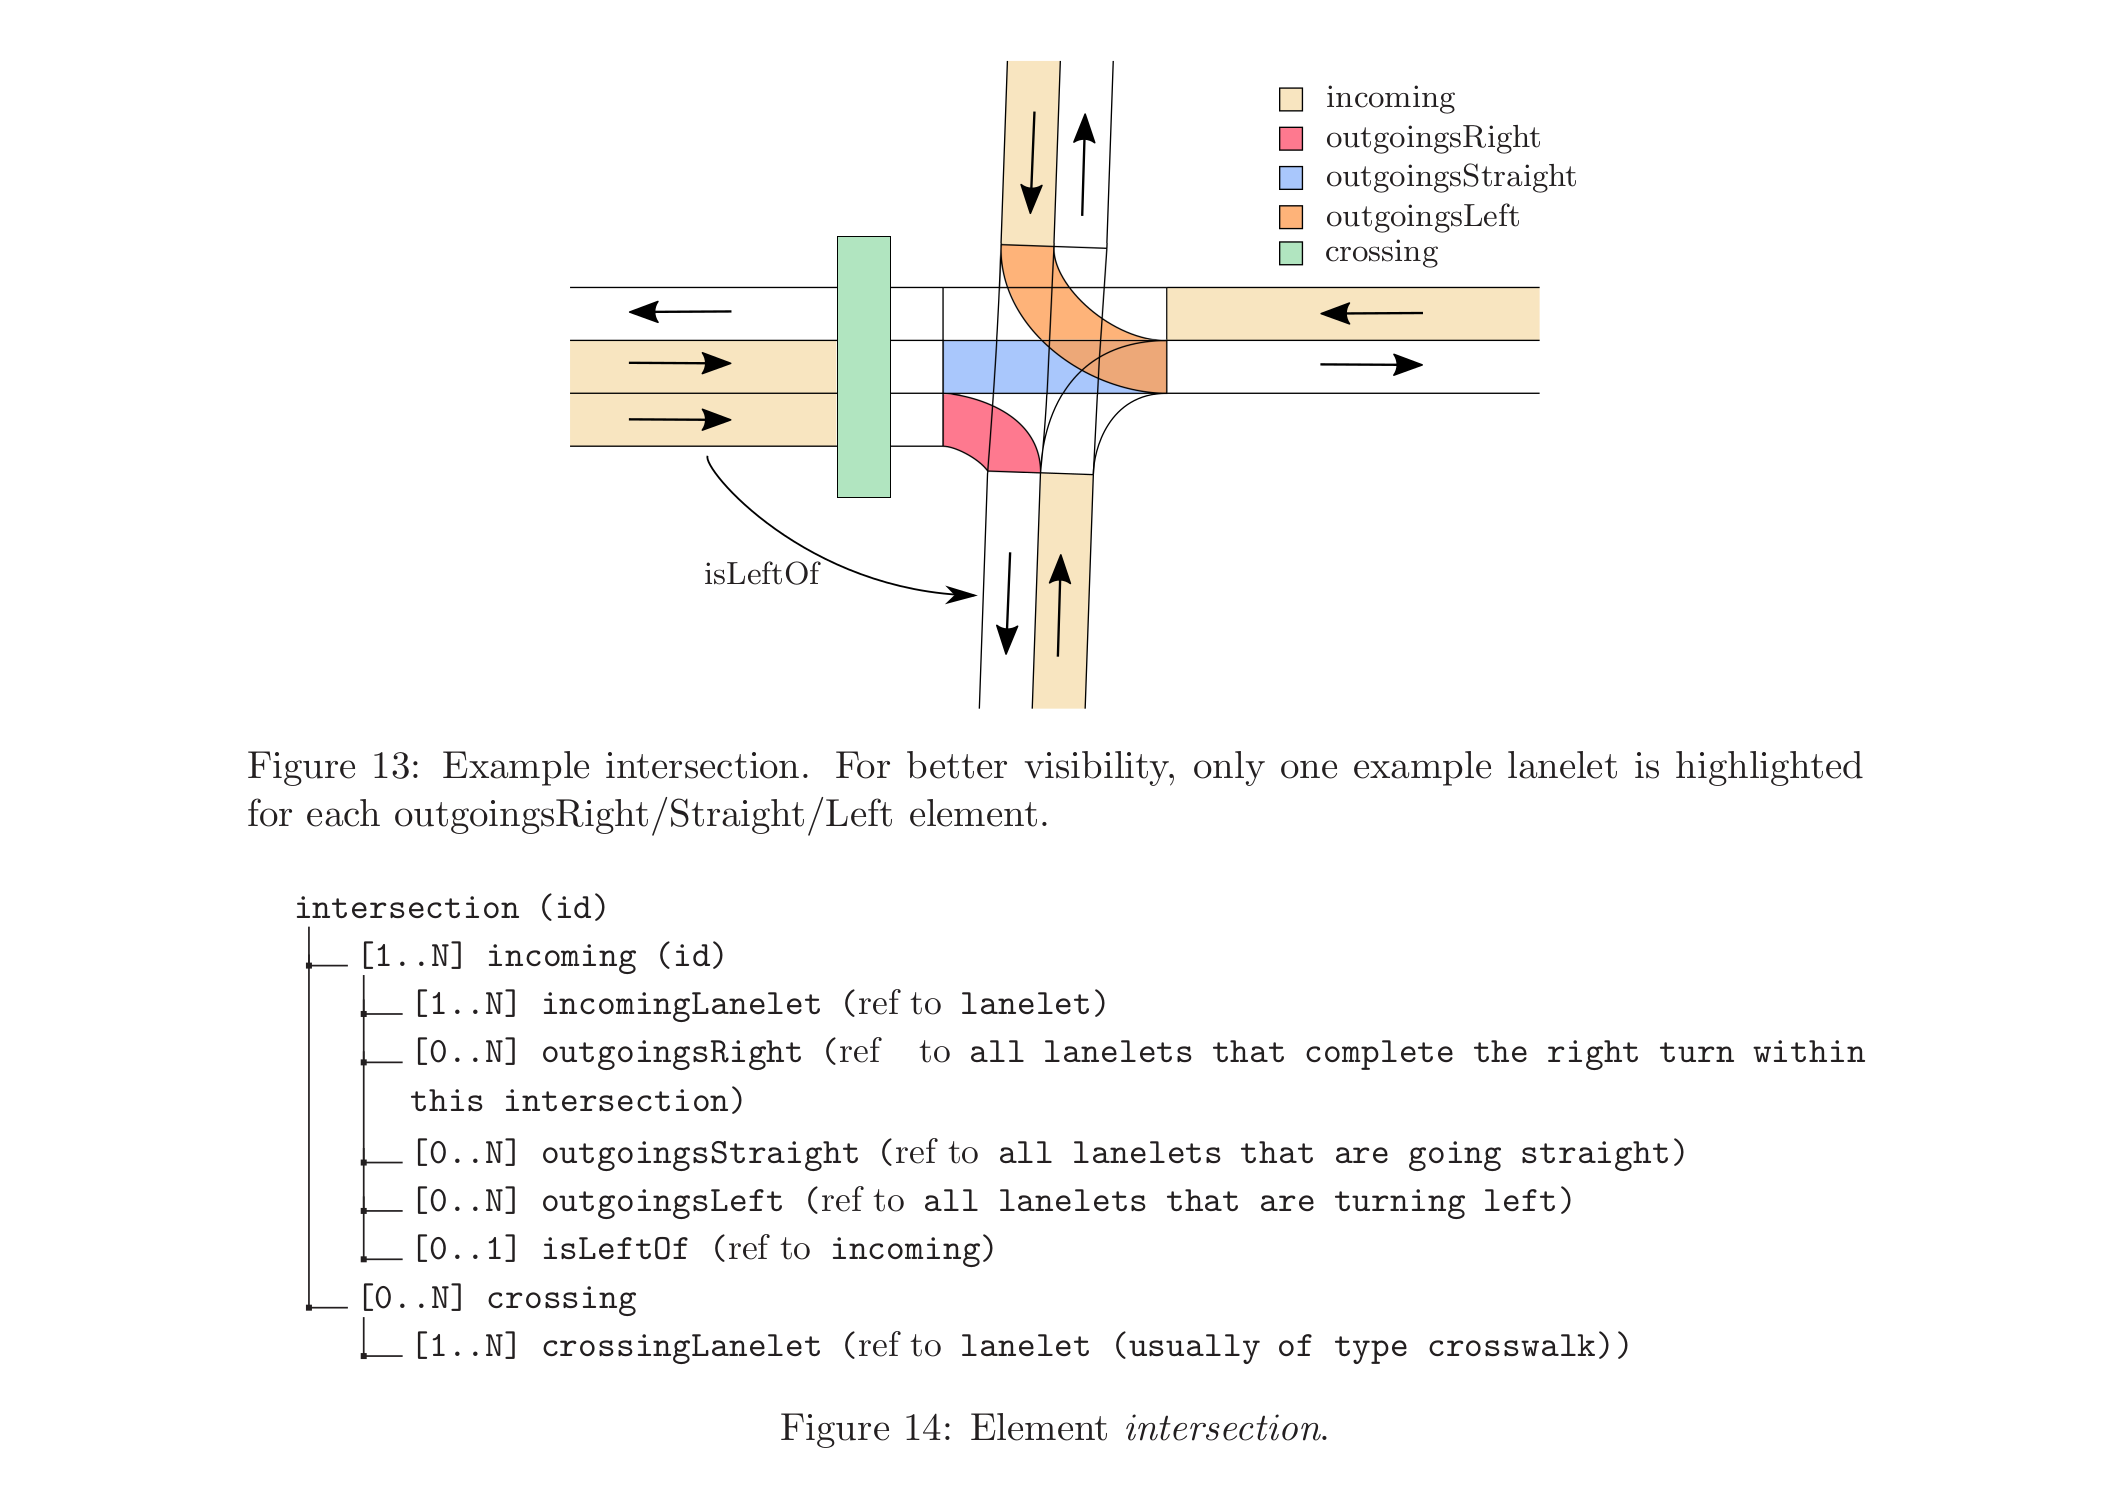

## 1. Read different intersection scenarios

This tutorial can deal with most of the CommonRoad Intersection scenarios, e.g. the simple, complex, or multiple-intersection. Please uncomment the **file_path** for different cases.

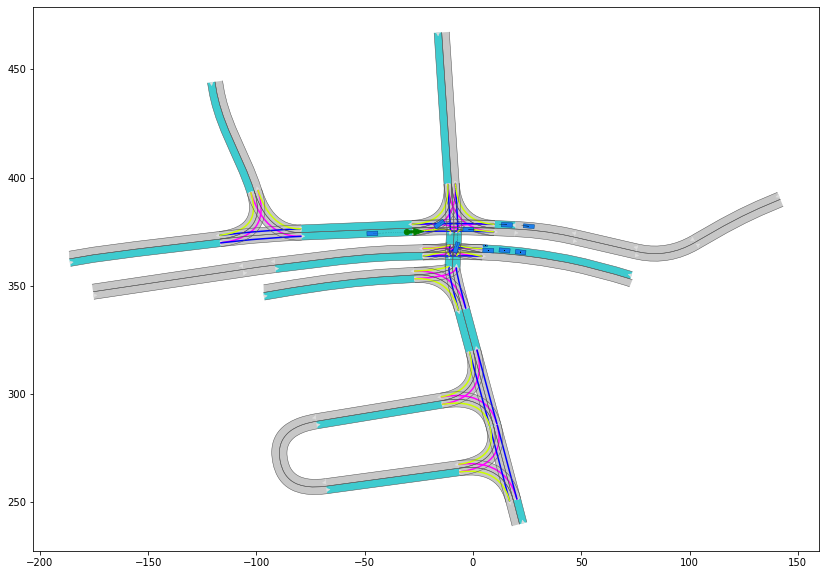

In [17]:
# import functions to read xml file and visualize commonroad objects
import os
import matplotlib.pyplot as plt
from IPython import display

# import functions to read xml file and visualize commonroad objects
from commonroad.common.file_reader import CommonRoadFileReader
from commonroad.visualization.mp_renderer import MPRenderer

from commonroad.common.file_writer import CommonRoadFileWriter
from commonroad.common.file_writer import OverwriteExistingFile
from commonroad.scenario.scenario import Location
from commonroad.scenario.scenario import Tag

# generate path of the file to be opened
#file_path = "./test/DEU_Speyer-2_2_T-1.xml"                        # simple 
#file_path = "./test/test_reading_intersection_traffic_sign.xml"    # simple
#file_path = "./test/USA_Lanker-2_1_T-1.xml"                        # multi-inter, not adjacent, complex 
#file_path = "./test/USA_Peach-4_8_T-1.xml"                         # adjacent, complex
#file_path = "./test/ZAM_Tjunction-1_19_T-1.xml"                    # single T-junction
#file_path = "./test/ESP_Monzon-2_4_T-1.xml"                        # multi-T-junction 
file_path = "./test/DEU_Muehlhausen-2_2_T-1.xml"                   # multi-inter

# read in the scenario and planning problem set
scenario, planning_problem_set = CommonRoadFileReader(file_path).open()

# plot the scenario for 40 time step, here each time step corresponds to 0.1 second
for i in range(0, 1):
    plt.figure(figsize=(25, 10))
    rnd = MPRenderer()
    # plot the scenario at different time step
    scenario.draw(rnd, draw_params={'time_begin': i})
    # plot the planning problem set
    planning_problem_set.draw(rnd)
    rnd.render()

## 2. Define Helper Function

In [15]:
import numpy as np

def get_angle(v1: np.ndarray, v2:np.ndarray) -> float:
    """
    Get clockwise angle between vectors
    
    :param v1: one vector
    :type v1: np.ndarray
    :param v2: another vector
    :type v2: np.ndarray
    :return: clockwise angle between vectors in degrees
    :rtype: float
    """
    x = [v1[0], v2[0]]
    y = [v1[1], v2[1]]
    angles = np.arctan2(y, x) + np.pi
    diff1 = angles[0] - angles[1]
    angle = diff1 / np.pi * 180
    return angle

In [3]:
def ref_v(network, incoming_index, incomings):
    """
    Get reference vector of incomings[incomint_index]
    
    :param network: scenario.lanelet_network
    :param incoming_index: specific incoming index
    :param incomings: all incomings of one intersection
    :return: reference vector of one specific incoming
    :rtype: np.ndarray
    """
    lanelets = incomings[incoming_index].incoming_lanelets
    front_node, back_node = [], []

    for laneId in lanelets:
        lane = network.find_lanelet_by_id(laneId)
        front_node.append(lane.center_vertices[-1])
        if len(lane.center_vertices) > 4:
            back_node.append(lane.center_vertices[-4])
        else:
            back_node.append(lane.center_vertices[0])

    front_node.sort(key=lambda tup: tup[0])
    back_node.sort(key=lambda tup: tup[0])

    ref = 0.5*(front_node[-1] + front_node[0]) - 0.5*(back_node[-1] + back_node[0])
    
    return ref

In [4]:
# threshold which is used to determine if a successor of an incoming lane is considered as straight
INTERSECTION_STRAIGHT_THRESHOLD = 35.0

def compute_left_list(network, incomings, incomings_id):
    """
    Find clockwise order for the incomings

    :param incomings: incomings of one intersection
    :param incomings_id: List of the id of the incomings
    :return: list of incomings in clockwise order
    """
    left_list = []

    # choose a reference incoming vector
    ref = ref_v(network, 0, incomings)
    angles = [(0, 0)]

    # calculate all incoming angle from the reference incoming vector
    for index in range(1, len(incomings)):
        new_v = ref_v(network, index, incomings)
        angle = get_angle(ref, new_v)
        if angle < 0:
            angle += 360
        angles.append((index, angle))

    # sort the angles from the reference to go clockwise
    angles.sort(key=lambda tup: tup[1])
    prev = -1
    
    # take the incomings which have less than 90 degrees in between
    for index in range(0, len(incomings)):
        angle = angles[index][1] - angles[prev][1]
        if angle < 0:
            angle += 360

        # add is_left_of relation if angle is less than intersection straight treshold
        if angle <= 180 - INTERSECTION_STRAIGHT_THRESHOLD:
            # is left of the previous incoming
            is_left_of = angles[prev][0]
            left_list.append(incomings_id[is_left_of])
        else:
            left_list.append(incomings_id[angles[prev][0]])
            left_list.append(None)

        prev = index

    return left_list

In [5]:
from commonroad.geometry.shape import Rectangle
from commonroad.geometry.polyline_util import compute_polyline_orientations
from numpy.linalg import norm

def is_adjacent_lanelet(network, inter_ind, lanelet_id, incoming_id):
    """
    check whehter the lanelet is adjacent to the incoming
    
    :param network: scenario.lanelet_network
    :param inter_ind: index of the specific intersection
    :param lanelet_id: lanelet id of the specific lanelet 
    :param incoming_id: incoming id of the specific incoming
    :return: True or False
    """
    lane = network.find_lanelet_by_id(lanelet_id)
    
    orientation = compute_polyline_orientations(lane.center_vertices)
    center = lane.center_vertices[0]
    lane_width = norm(lane.right_vertices[0] - lane.left_vertices[0])

    enlarged_shape = Rectangle(length=2*lane_width, width=4*lane_width, 
                               center=center, orientation=orientation[0])
    adjacent_lanelets = network.find_lanelet_by_shape(enlarged_shape)
    #print(adjacent_lanelets)
    
    incoming_list = []
    incomings = network.intersections[inter_ind].incomings
    for i in range(len(incomings)):
        incoming_list.append(incomings[i].incoming_id)
    
    incoming_index = incoming_list.index(incoming_id)
    incoming_lanelets = incomings[incoming_index].incoming_lanelets
    #print(incoming_lanelets)
    
    if set(adjacent_lanelets) & set(incoming_lanelets):
        return True
    else:
        return False

## 3. Assign Intersection Elements

The main difference of the new definition consists in **OutgoingsStraigt**, **outgoingsRight** and **outgoingsLeft**. The following method iterates all the intersections and all the incomings. It first computes the clockwise order for the incomings, then figures out the left and opposite incomings using Function **compute_left_list()**, finally assigns **OutgoingsStraigt**, **outgoingsRight** and **outgoingsLeft** using Function **is_adjacent_lanelet()**. In particular, we assign the lanelet to be **OutgoingsStraigt** (**OutgoingsLeft**) only when the successor lanelets of this lanelet are adjacent to the opposite (left) incomings. 

In [9]:
print(len(scenario.lanelet_network.intersections))
for i in range(len(scenario.lanelet_network.intersections)):
    print('intersection_id:', scenario.lanelet_network.intersections[i].intersection_id)
    print('intersection.crossing:', scenario.lanelet_network.intersections[i].crossings, '\n')

3
intersection_id: 75541
intersection.crossing: set() 

intersection_id: 74863
intersection.crossing: set() 

intersection_id: 75213
intersection.crossing: set() 



In [16]:
network = scenario.lanelet_network

for inter_ind in range(len(network.intersections)):
    incoming_list = []
    incomings = network.intersections[inter_ind].incomings
    for i in range(len(incomings)):
        incoming_list.append(incomings[i].incoming_id)

    left_list = compute_left_list(network, incomings, incoming_list)
    print('intersection:', network.intersections[inter_ind].intersection_id, ', left_list:', left_list)

    for index in range(len(incoming_list)):
        straight, left, right = [], [], []

        # opposite_index/left_index represent the opposite/left incoming 
        left_list_index = left_list.index(incoming_list[index])
        if (left_list_index + 2) < len(left_list):
            if left_list[left_list_index + 2] is not None:
                opposite_index = incoming_list.index(left_list[left_list_index + 2])
            else:
                opposite_index = None
        elif left_list[left_list_index - 2] is not None:
            opposite_index = incoming_list.index(left_list[left_list_index - 2])
        else:
            opposite_index = None

        if (left_list_index + 1) < len(left_list):
            if left_list[left_list_index + 1] is not None:
                left_index = incoming_list.index(left_list[left_list_index + 1])
            else:
                left_index = None
        elif left_list[0] is not None:
            left_index = incoming_list.index(left_list[0])
        else:
            left_index = None

        print('incoming:', incoming_list[index])
        if left_index is not None:
            print('left:', incoming_list[left_index])
        if opposite_index is not None:
            print('opposite:', incoming_list[opposite_index])

        # OutgoingsStraight
        for item in (incomings[index].successors_straight):
            lane_straight = network.find_lanelet_by_id(item)
            
            if len(lane_straight.successor) == 0:
                straight.append(lane_straight.lanelet_id)
            else:                
                succ_lane = network.find_lanelet_by_id(lane_straight.successor[0])

                # single straight lanelet in simple scenario
                if is_adjacent_lanelet(network, inter_ind, lane_straight.successor[0], incoming_list[opposite_index]):
                    straight.append(lane_straight.lanelet_id)

                else:
                    lane_straight_2 = network.find_lanelet_by_id(lane_straight.successor[0])
                    succ_lane_2 = network.find_lanelet_by_id(lane_straight_2.successor[0])

                    if is_adjacent_lanelet(network, inter_ind, lane_straight_2.successor[0], incoming_list[opposite_index]):
                        straight.append(lane_straight_2.lanelet_id)

                    else:
                        lane_straight_3 = network.find_lanelet_by_id(lane_straight_2.successor[0])
                        succ_lane_3 = network.find_lanelet_by_id(lane_straight_3.successor[0])

                        # multiple straight lanelets in complex scenario
                        if succ_lane_3.adj_left_same_direction:
                            succ_lane_3_adj = network.find_lanelet_by_id(succ_lane_3.adj_left)

                            if is_adjacent_lanelet(network, inter_ind, succ_lane_3.adj_left, incoming_list[opposite_index]):
                                straight.append(lane_straight_3.lanelet_id)

                            elif is_adjacent_lanelet(network, inter_ind, succ_lane_3_adj.adj_left, incoming_list[opposite_index]):
                                straight.append(lane_straight_3.lanelet_id)

                        elif is_adjacent_lanelet(network, inter_ind, lane_straight_3.successor[0], incoming_list[opposite_index]):
                            straight.append(lane_straight_3.lanelet_id)

        # OutgoingsRight
        for item in (incomings[index].successors_right):
            right.append(item)

        # OutgoingsLeft
        for item in (incomings[index].successors_left):
            lane_left = network.find_lanelet_by_id(item)

            for i in range(len(lane_left.successor)):
                succ_lane = network.find_lanelet_by_id(lane_left.successor[i])

                # single left lane in simple scenario
                if is_adjacent_lanelet(network, inter_ind, lane_left.successor[i], incoming_list[left_index]):
                    left.append(lane_left.lanelet_id)

                elif len(succ_lane.successor) != 0:
                    lane_left_2 = network.find_lanelet_by_id(lane_left.successor[i])
                    succ_lane_2 = network.find_lanelet_by_id(succ_lane.successor[0])

                    if is_adjacent_lanelet(network, inter_ind, lane_left_2.successor[0], incoming_list[left_index]):
                        left.append(lane_left_2.lanelet_id)

                    elif succ_lane_2.adj_left_same_direction:
                        if is_adjacent_lanelet(network, inter_ind, succ_lane_2.adj_left, incoming_list[left_index]):
                            left.append(lane_left_2.lanelet_id)

                    else:
                        lane_left_3 = network.find_lanelet_by_id(lane_left_2.successor[0])
                        succ_lane_3 = network.find_lanelet_by_id(lane_left_3.successor[0])

                        if is_adjacent_lanelet(network, inter_ind, lane_left_3.successor[0], incoming_list[left_index]):
                            left.append(lane_left_3.lanelet_id)

        print(straight, left, right, '\n')

intersection: 8608 , left_list: [8606, 8604, 8607, 8605]
incoming: 8604
left: 8607
opposite: 8605
[6713] [6714] [6715] 

incoming: 8605
left: 8606
opposite: 8604
[6456] [6457] [6455] 

incoming: 8606
left: 8604
opposite: 8607
[6758] [6757] [6756] 

incoming: 8607
left: 8605
opposite: 8606
[6988] [6986] [6987] 

intersection: 8418 , left_list: [8416, 8414, 8417, 8415]
incoming: 8414
left: 8417
opposite: 8415
[8340] [8341] [8339] 

incoming: 8415
left: 8416
opposite: 8414
[8292] [8293] [8294] 

incoming: 8416
left: 8414
opposite: 8417
[6917] [6915] [6916] 

incoming: 8417
left: 8415
opposite: 8416
[6961] [6963] [6962] 

intersection: 8990 , left_list: [8989, None, 8987, 8988]
incoming: 8987
left: 8988
opposite: 8989
[6960] [6959] [] 

incoming: 8988
left: 8989
[] [7085] [7086] 

incoming: 8989
opposite: 8987
[6989] [] [6990] 

intersection: 8786 , left_list: [8784, 8783, 8785, None]
incoming: 8783
left: 8785
[] [7145] [7146] 

incoming: 8784
left: 8783
opposite: 8785
[6610] [6588] [] 

i